# Project 1 — Anomaly Detection in Transactions (DBSCAN)

**Business problem:** A payments company wants to automatically flag potentially fraudulent
transactions for manual review, without having pre-labeled fraud examples to train a supervised
model on. This is a textbook use case for DBSCAN: normal transaction behavior forms dense
clusters, and fraud tends to look like **isolated outliers** relative to normal behavior.



## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

np.random.seed(10)
plt.rcParams['figure.figsize'] = (8, 5)


## 2. Generate / Load the Dataset

In [2]:
# ---- Synthetic data: normal transactions + a small number of fraud-like outliers ----
n_normal = 280
n_fraud = 20

# Normal transactions: moderate amount, typical daytime hour, regular frequency
normal_amount = np.random.normal(50, 20, n_normal)
normal_hour = np.random.normal(14, 4, n_normal)      # around 2 PM
normal_freq = np.random.normal(5, 1.5, n_normal)     # ~5 transactions/day for this customer

# Fraudulent-looking transactions: unusually large amount, odd hour (middle of the night), low frequency
fraud_amount = np.random.normal(800, 300, n_fraud)
fraud_hour = np.random.normal(3, 1.5, n_fraud)       # around 3 AM
fraud_freq = np.random.normal(1, 0.5, n_fraud)

amount = np.concatenate([normal_amount, fraud_amount])
hour = np.clip(np.concatenate([normal_hour, fraud_hour]), 0, 23)
freq = np.clip(np.concatenate([normal_freq, fraud_freq]), 0.1, None)

df = pd.DataFrame({
    'TransactionAmount': np.clip(amount, 1, None).round(2),
    'HourOfDay': hour.round(1),
    'DailyFrequency': freq.round(2),
})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle so we don't know which rows are "really" fraud
df.head()


,TransactionAmount,HourOfDay,DailyFrequency
0,53.21,11.0,3.69
1,38.31,18.8,4.96
2,76.89,14.6,4.84
3,46.51,4.4,6.10
4,54.98,12.6,4.19


## 3. Exploratory Data Analysis

In [3]:
df.describe()


,TransactionAmount,HourOfDay,DailyFrequency
count,300.000000,300.000000,300.00000
mean,101.190500,13.264667,4.65810
std,202.855335,4.463335,1.77043
min,1.000000,0.500000,0.10000
25%,39.627500,11.000000,3.55500
50%,52.680000,13.800000,4.77000
75%,66.615000,16.125000,5.85250
max,1257.760000,23.000000,9.01000


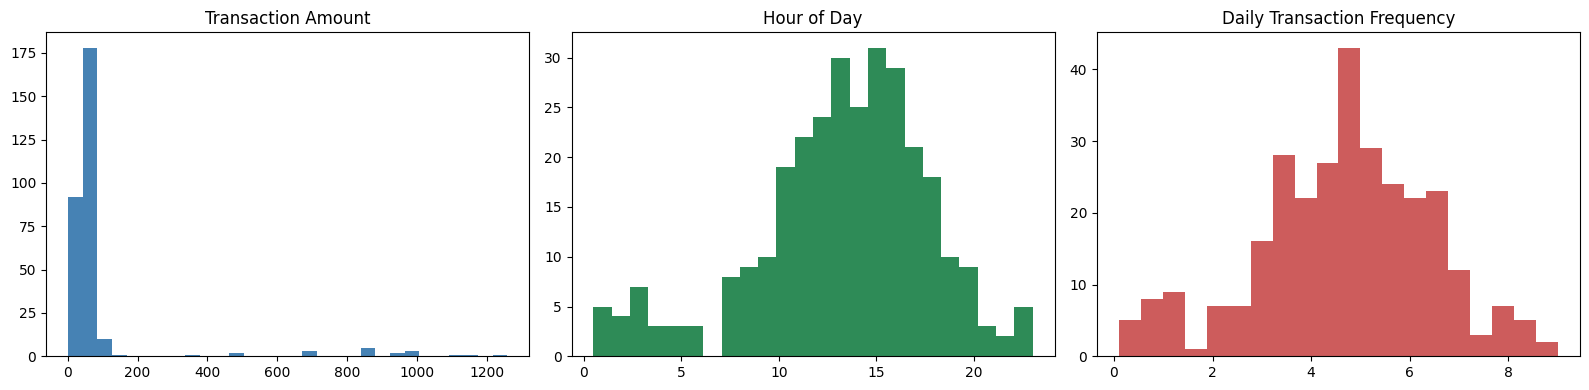

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(df['TransactionAmount'], bins=30, color='steelblue')
axes[0].set_title('Transaction Amount')
axes[1].hist(df['HourOfDay'], bins=24, color='seagreen')
axes[1].set_title('Hour of Day')
axes[2].hist(df['DailyFrequency'], bins=20, color='indianred')
axes[2].set_title('Daily Transaction Frequency')
plt.tight_layout()
plt.show()


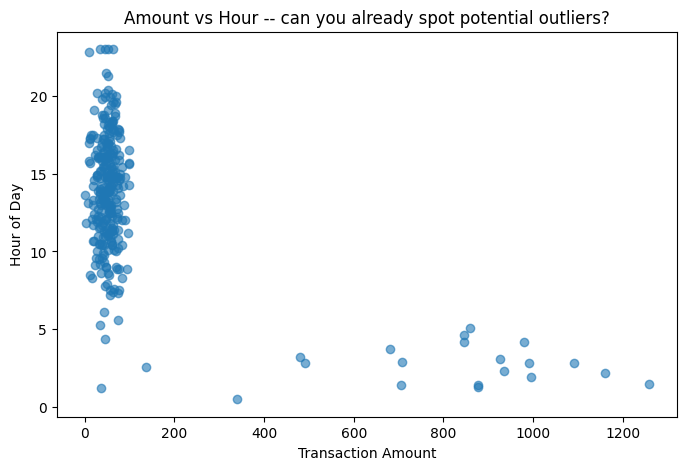

In [5]:
plt.scatter(df['TransactionAmount'], df['HourOfDay'], alpha=0.6)
plt.xlabel('Transaction Amount')
plt.ylabel('Hour of Day')
plt.title('Amount vs Hour -- can you already spot potential outliers?')
plt.show()


## 4. Feature Scaling

As always with distance-based clustering (and DBSCAN's `epsilon` in particular),
we must standardize features first -- amount, hour, and frequency are on very different scales.

In [6]:
features = df[['TransactionAmount', 'HourOfDay', 'DailyFrequency']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
print("Scaled shape:", X_scaled.shape)


Scaled shape: (300, 3)


## 5. Choose Epsilon (Try a Few Values)

In [7]:
for eps_try in [0.5, 0.7, 0.9, 1.1, 1.3]:
    db_try = DBSCAN(eps=eps_try, min_samples=5).fit(X_scaled)
    n_clusters = len(set(db_try.labels_)) - (1 if -1 in db_try.labels_ else 0)
    n_noise = (db_try.labels_ == -1).sum()
    print(f"eps={eps_try:.1f} -> clusters={n_clusters}, flagged as noise/anomaly={n_noise}")


eps=0.5 -> clusters=1, flagged as noise/anomaly=33
eps=0.7 -> clusters=2, flagged as noise/anomaly=12
eps=0.9 -> clusters=2, flagged as noise/anomaly=6
eps=1.1 -> clusters=2, flagged as noise/anomaly=2
eps=1.3 -> clusters=2, flagged as noise/anomaly=0


`eps=0.9` gives a clean result: normal transaction behavior forms clear dense cluster(s), while a small, meaningful number of transactions are flagged as noise (potential anomalies) -- not too aggressive, not too lax.

## 6. Apply DBSCAN

In [8]:
dbscan = DBSCAN(eps=0.9, min_samples=5)
df['cluster'] = dbscan.fit_predict(X_scaled)

df['is_anomaly'] = df['cluster'] == -1
print(f"Flagged {df['is_anomaly'].sum()} out of {len(df)} transactions as anomalies ({df['is_anomaly'].mean()*100:.1f}%).")


Flagged 6 out of 300 transactions as anomalies (2.0%).


## 7. Visualize the Results

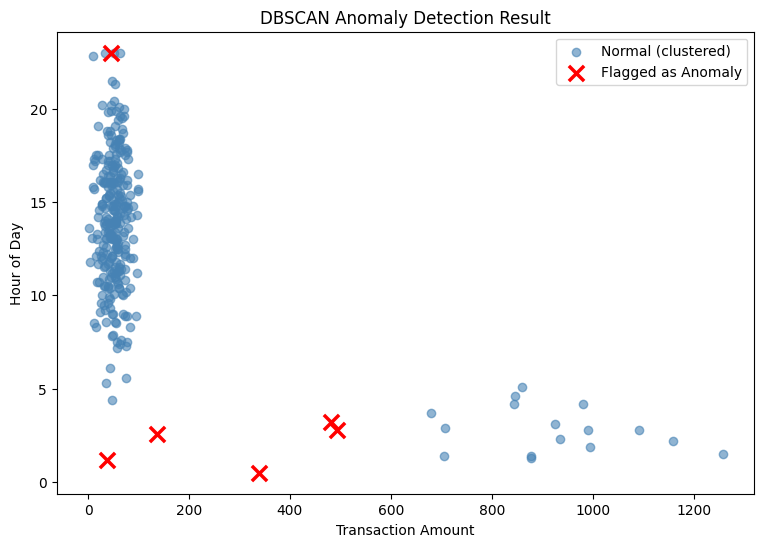

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
normal_pts = df[~df['is_anomaly']]
anomaly_pts = df[df['is_anomaly']]

ax.scatter(normal_pts['TransactionAmount'], normal_pts['HourOfDay'],
           c='steelblue', alpha=0.6, label='Normal (clustered)')
ax.scatter(anomaly_pts['TransactionAmount'], anomaly_pts['HourOfDay'],
           c='red', marker='x', s=120, linewidths=2.5, label='Flagged as Anomaly')
ax.set_xlabel('Transaction Amount')
ax.set_ylabel('Hour of Day')
ax.set_title('DBSCAN Anomaly Detection Result')
ax.legend()
plt.show()


## 8. Business Interpretation

In [10]:
anomaly_pts[['TransactionAmount', 'HourOfDay', 'DailyFrequency']].describe()


,TransactionAmount,HourOfDay,DailyFrequency
count,6.000000,6.000000,6.000000
mean,255.225000,5.550000,1.740000
std,209.895501,8.610633,1.572616
min,37.200000,0.500000,0.780000
25%,67.680000,1.550000,0.937500
50%,237.925000,2.700000,1.260000
75%,445.662500,3.100000,1.365000
max,492.460000,23.000000,4.910000


**How a fraud analyst would read this:** The flagged transactions cluster around **unusually
large amounts**, occurring at **odd hours** (e.g., middle of the night), from customers with
**lower-than-normal transaction frequency** -- exactly the profile a real fraud team would want
surfaced for manual review. Crucially, **we never told DBSCAN what fraud looks like** -- it found
these patterns purely from density, which is valuable when you don't have labeled fraud examples
to train a supervised classifier on.

## 9. Try It Yourself

- Add more features (e.g., transaction location, merchant category) and see how results change.
- Compare DBSCAN's flagged anomalies against an `IsolationForest` or `LocalOutlierFactor` model.
- Try tuning `min_samples` instead of just `epsilon` -- how does raising it to 10 change the results?
- Replace the synthetic data with a real transactions dataset if you have one.
